In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import scipy
import sklearn
import utility
import json
import random
import matplotlib.gridspec as gridspec
from sklearn.cluster import OPTICS

In [147]:
random.seed(33)

### Load data

In [148]:
cwd = Path('.')
data_path = cwd / 'data' / 'data_imputated.csv'
data: pd.DataFrame = pd.read_csv(data_path)
data = data.iloc[:int(len(data)*0.11 / 12) * 12] # 10% of data for testing to make code run faster - must be divisible by 12 since each match has 12 rows
data_len = int(len(data) * 10 / 12)

C:\Users\dwarf\AppData\Local\Temp\ipykernel_24976\1708297752.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data: pd.DataFrame = pd.read_csv(data_path)


### Duplicating data and removing surplus rows

The data consists of rows of match statistics for specific players. 

Since each match has 2 teams of 5 players, you would expect 10 rows for each match. It turns out that there are 12 rows for each match because there are 2 extra rows that contain information about the team as a whole, rather than the players. 

Since we want to analyze the players, we take the teamwide information contained in these 2 rows (which is simply missing information in the player rows) and duplicate it to the player rows of those teams in the places that the players are missing data (if present in the team data). 

We then drop all rows that only contain teamwide statistics, as we are interested only in the player performances

In [149]:
data = data.drop(data[data["position"] == "team"].index) 

### Clean data for missing data and unrelated columns

Currently the data is full of missing values as can be seen on the missing value plot below, so we remove the the columns that have many missing values and then the rows that have many missing values. 

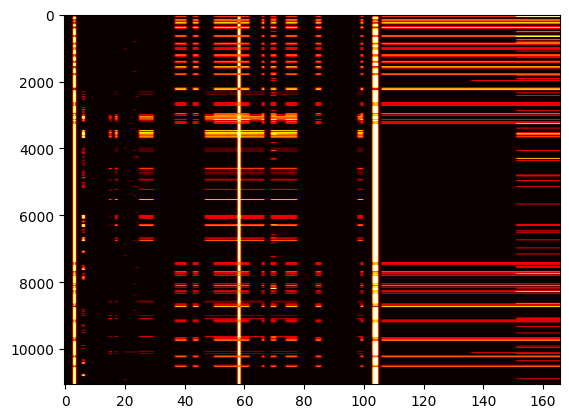

In [150]:
plt.imshow(data.isnull(), cmap='hot', aspect='auto')
plt.show()

In [151]:

# drop columns with more than a given percentage of missing values
missing_value_column_percentage_threshold = 0.05
missing_values = data.isnull().sum()
missing_value_columns = missing_values[missing_values > len(data) * missing_value_column_percentage_threshold].index
data = data.drop(columns=missing_value_columns)

# drop 10-rows (matches) with more than a given percentage of missing values
missing_value_row_percentage_threshold = 0
z = data.isnull().sum(axis=1)
gameids = data[z > len(data.columns) * missing_value_row_percentage_threshold]["gameid"].unique()

data = data.drop(data[data["gameid"].isin(gameids)].index)

The remaining data no longer contains a large amount of missing data as can be seen on the graph below, and still has 

In [152]:
100 * len(data) / data_len

89.86425339366515

In [153]:
len(data) / 10

993.0

% of the data rows

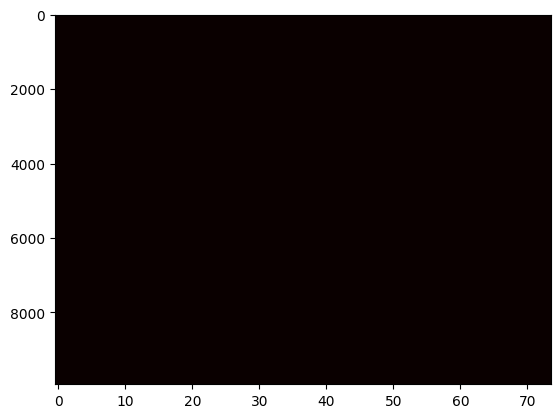

In [154]:
plt.imshow(data.isnull(), cmap='hot', aspect='auto')
plt.show()

### Modelling categorical variables as multivariate bernoulli variables (one-hot encoding)

In [155]:
# drop irrelevant columns
data_pure = data.drop(columns=["gameid", "datacompleteness", "league", "year", "playoffs", "date", "game", "patch", "participantid", "playername", "playerid", "teamname", "teamid"])

In [156]:
# convert categorical columns to one-hot encoding
data_numeric = pd.get_dummies(data_pure, dtype=float)
X = data_numeric.to_numpy()
X.shape

(9930, 1249)

### Normalize data and calculate covariance and correlation matrix

In [157]:
X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

# calculate the zero-centered data matrix and the covariance matrix
X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

# calculate the standard score normalized matrix and the correlation matrix
X_normalized = scipy.stats.zscore(X, axis=1)    # (x - mean) / std
X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)

### Clustering of unknown quantity

We are also interested in finding out if there is some pattern in the players perfomance, are there clear clusters showing potential different types of perfomance, EG a average performance, above average, below average. Yet unlike above there is no base truth that we can compare it to so it makes more sense to use clustering density clustering algorithmns like DBSCAN to try and find clusters of perfomances that are similar to eachother.

Ideally we want points that are somewhat close, but we want a relatively high MinPts since we are looking to find more generalized clusters rather than highly specific clusters

In [158]:
X_hat = X_normalized


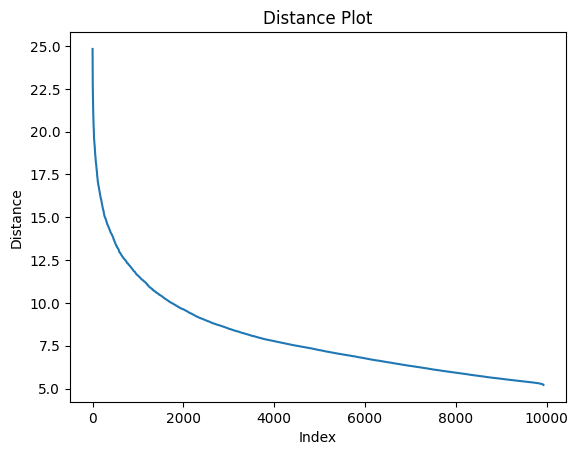

In [159]:
def create_distance_plot(X_hat, neighbors):
    nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=neighbors ).fit(X_hat)
    distances, indices = nbrs.kneighbors(X_hat)
    distance_desc = sorted(distances[:,neighbors-1], reverse=True)
    plt.plot(
        range(1, len(distance_desc) + 1),
        distance_desc
    )

    plt.xlabel("Index")
    plt.ylabel("Distance")
    plt.title("Distance Plot")

    plt.show()
neighbors = 2*X_hat.shape[1]
create_distance_plot(X_hat,neighbors)

In [160]:
density_cluster = sklearn.cluster.DBSCAN(eps=11.0, min_samples = neighbors).fit(X_hat)

In [161]:
labels = np.unique(density_cluster.labels_)
labels

array([-1,  0], dtype=int64)

We are seeing one cluster, instead we will set the min pts manually and decide that 20 perfomances should be good

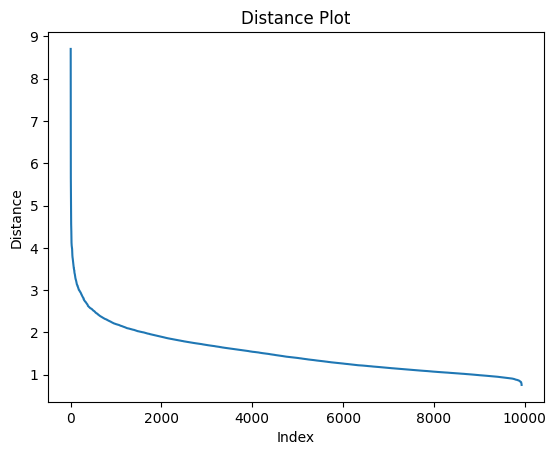

In [162]:
create_distance_plot(X_hat,20)

In [163]:
density_cluster = sklearn.cluster.DBSCAN(eps=2.5, min_samples = neighbors).fit(X_hat)
unique_labels = np.unique(density_cluster.labels_)
labels = density_cluster.labels_
unique_labels

array([-1], dtype=int64)

In [164]:
label_counts = np.unique(labels, return_counts=True)
label_counts

(array([-1], dtype=int64), array([9930], dtype=int64))

We are not getting any clusters at all, so lets try to visualize it

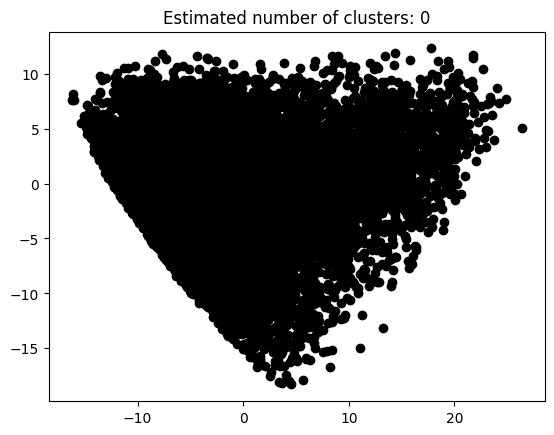

In [165]:
pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat)
X_pca = pca.transform(X_hat)

core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[density_cluster.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X_pca[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X_pca[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {len(unique_labels)-1}")
plt.show()

This can be read as each performance being so vastly different that they are not clustered together, however this is unlikely, but in order to find out if we can even get any results using these methods lets start by tring to instead cluster similar matches, but also lower the number of parameters we are looking at by manually selecting the most imporant columns


# Clustering similar matches

We load in the data just as before, however this time we only select a few columns, looking only at the team rows and combining both team rows into an individual match row

In [166]:
cwd = Path('.')
data_path = cwd / 'data' / 'data_imputated.csv'
data: pd.DataFrame = pd.read_csv(data_path)
data = data.iloc[:int(len(data)*0.11 / 12) * 12] # 10% of data for testing to make code run faster - must be divisible by 12 since each match has 12 rows
data_len = int(len(data) * 10 / 12)
data.drop(data.columns[[0]], axis=1, inplace=True)

data = data.drop(data[data["position"] != "team"].index) 
# drop columns with more than a given percentage of missing values
missing_value_column_percentage_threshold = 0.2
missing_values = data.isnull().sum()
missing_value_columns = missing_values[missing_values > len(data) * missing_value_column_percentage_threshold].index
data = data.drop(columns=missing_value_columns)

# drop 10-rows (matches) with more than a given percentage of missing values
missing_value_row_percentage_threshold = 0
z = data.isnull().sum(axis=1)
gameids = data[z > len(data.columns) * missing_value_row_percentage_threshold]["gameid"].unique()

data = data.drop(data[data["gameid"].isin(gameids)].index)

data_pure = data.drop(columns=["datacompleteness", "year", "playoffs", "date", "game", "patch", "participantid", "teamid"])


most_relevant_columns = ['gameid','side','gamelength','kills', 'deaths', 'assists','damagetochampions', 'dpm', 'damagetakenperminute', 'damagemitigatedperminute', 'damagetotowers', 'wardsplaced', 'visionscore', 'totalgold', 'minionkills', 'monsterkills', 'xpat10', 'csat10', 'goldat10', 'xpat15', 'csat15', 'goldat15', 'xpat20', 'csat20', 'goldat20', 'xpat25', 'csat25', 'goldat25']
data_pure = data[most_relevant_columns]
data_pure = data_pure.pivot(index=['gameid'],columns='side')
data_numeric = pd.get_dummies(data_pure, dtype=float)
X = data_numeric.to_numpy()
X.shape

X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

# calculate the zero-centered data matrix and the covariance matrix
X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

# calculate the standard score normalized matrix and the correlation matrix
X_normalized = scipy.stats.zscore(X, axis=0)    # (x - mean) / std
X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)



C:\Users\dwarf\AppData\Local\Temp\ipykernel_24976\1064662906.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data: pd.DataFrame = pd.read_csv(data_path)


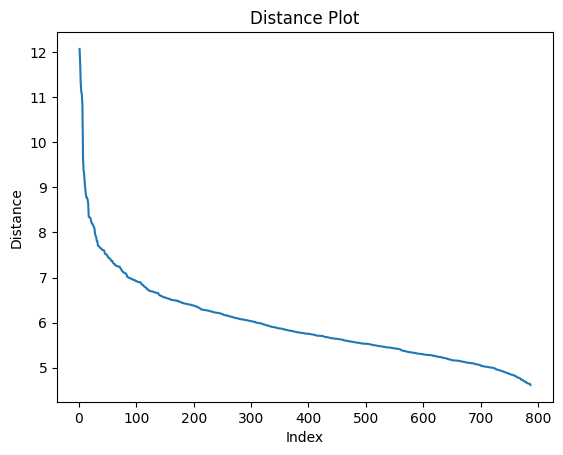

In [167]:
X_hat = X_normalized
pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat)
X_pca = pca.transform(X_hat)

neighbors = 30
create_distance_plot(X_hat,neighbors)

In [168]:
density_cluster = sklearn.cluster.DBSCAN(eps=7, min_samples = neighbors).fit(X_hat)
unique_labels = np.unique(density_cluster.labels_)
labels = density_cluster.labels_
unique_labels

array([-1,  0], dtype=int64)

In [169]:
label_counts = np.unique(labels, return_counts=True)
label_counts

(array([-1,  0], dtype=int64), array([ 13, 774], dtype=int64))

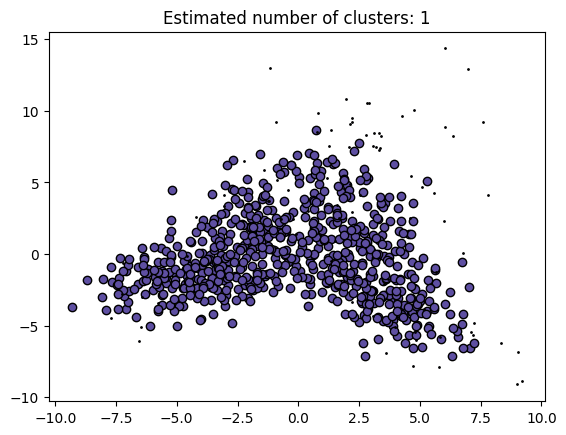

In [170]:
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[density_cluster.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X_pca[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

    xy = X_pca[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=1,
        
    )

plt.title(f"Estimated number of clusters: {len(unique_labels)-1}")
plt.show()

While we are still only finding one cluster it does visually look more like there are two distinct clusters, so we are going to use a different method

We can try to use OPTICS instead since it is better suited for such high dimensional data

In [172]:
clust = OPTICS(min_samples=50, cluster_method='dbscan',max_eps=5.0)

clust.fit(X_normalized)

np.unique(clust.labels_)

array([-1,  0,  1])

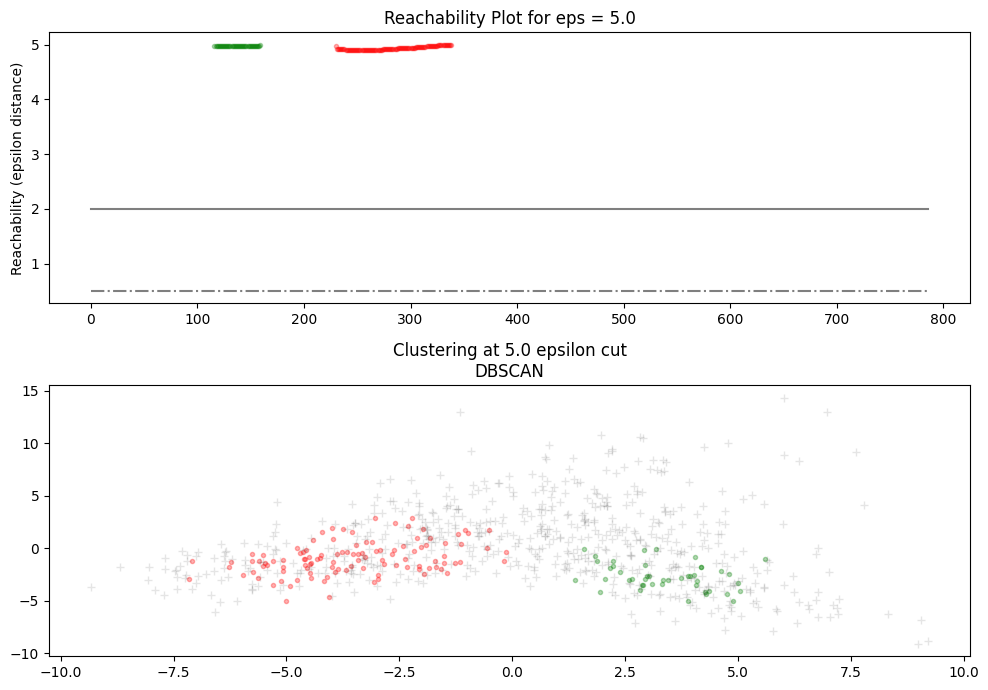

In [174]:
def create_optics_plot(X_hat,X_pca,clust,eps_val):
    space = np.arange(len(X_hat))
    reachability = clust.reachability_[clust.ordering_]
    labels = clust.labels_[clust.ordering_]

    plt.figure(figsize=(10, 7))
    G = gridspec.GridSpec(2, 3)
    ax1 = plt.subplot(G[0, :])
    ax2 = plt.subplot(G[1, :])


    # Reachability plot
    colors = ["g.", "r.", "b.", "y.", "c."]
    for klass, color in enumerate(colors):
        Xk = space[labels == klass]
        Rk = reachability[labels == klass]
        ax1.plot(Xk, Rk, color, alpha=0.3)
    ax1.plot(space[labels == -1], reachability[labels == -1], "k.", alpha=0.3)
    ax1.plot(space, np.full_like(space, 2.0, dtype=float), "k-", alpha=0.5)
    ax1.plot(space, np.full_like(space, 0.5, dtype=float), "k-.", alpha=0.5)
    ax1.set_ylabel("Reachability (epsilon distance)")
    ax1.set_title("Reachability Plot for eps = " + str(eps_val))

    # OPTICS
    colors = ["g.", "r.", "b.", "y.", "c."]
    for klass, color in enumerate(colors):
        Xk = X_pca[clust.labels_ == klass]
        ax2.plot(Xk[:, 0], Xk[:, 1], color, alpha=0.3)
    ax2.plot(X_pca[clust.labels_ == -1, 0], X_pca[clust.labels_ == -1, 1], "k+", alpha=0.1)
    ax2.set_title("Clustering at " + str(eps_val) +" epsilon cut\nDBSCAN")


    plt.tight_layout()
    plt.show()
create_optics_plot(X_hat, X_pca, clust, eps_val= 5.0)

Now we are beginning to see 2 clusters, however they are not that far from eachother as seen in the reachability plot and they are quite susceptible to change with even small changes to epsillon,and a large portion of the points are not part of any cluster. So regardless of what we find these clusters do not appear to be very strong, however we now need to investigate the points in the clusters and see what type of matches these clusters are.

In [175]:
data_pure['cluster'] = clust.labels_

cluster_means = data_pure.groupby('cluster').mean()
cluster_means

gamelength                   kills                deaths             \
side            Blue          Red       Blue        Red       Blue        Red   
cluster                                                                         
-1       2010.908228  2010.908228  16.104430  15.830696  15.884494  16.153481   
 0       1785.688889  1785.688889   6.266667  18.733333  18.777778   6.311111   
 1       1809.236364  1809.236364  18.718182   6.918182   6.963636  18.736364   

           assists            damagetochampions                ...  \
side          Blue        Red              Blue           Red  ...   
cluster                                                        ...   
-1       38.061709  37.120253      92995.537975  92516.096519  ...   
 0       14.088889  45.244444      62656.644444  81036.000000  ...   
 1       45.709091  14.945455      83153.272727  62965.872727  ...   

             csat20                  goldat20                      xpat25  \
side           Blue         Red          Blue           Red          Blue   
cluster                                                                     
-1       689.930380  693.905063  34437.324367  34235.735759  52989.651899   
 0       696.933333  724.822222  32659.133333  35324.688889  51179.822222   
 1       719.363636  697.654545  35743.900000  32737.990909  55408.554545   

                           csat25                  goldat25                
side              Red        Blue         Red          Blue           Red  
cluster                                                                    
-1       53143.028481  842.713608  847.314873  43677.993671  43424.495253  
 0       56338.600000  848.800000  896.022222  40568.511111  46088.311111  
 1       51242.436364  880.963636  850.527273  45861.063636  40851.845455  

[3 rows x 52 columns]

In [176]:
diff = cluster_means.loc[0] - cluster_means.loc[1]
diff

                          side
gamelength                Blue      -23.547475
                          Red       -23.547475
kills                     Blue      -12.451515
                          Red        11.815152
deaths                    Blue       11.814141
                          Red       -12.425253
assists                   Blue      -31.620202
                          Red        30.298990
damagetochampions         Blue   -20496.628283
                          Red     18070.127273
dpm                       Blue     -653.840000
                          Red       648.964286
damagetakenperminute      Blue      289.187302
                          Red      -255.850421
damagemitigatedperminute  Blue     -331.247944
                          Red       166.545239
damagetotowers            Blue   -17822.516162
                          Red     17118.580808
wardsplaced               Blue       -3.918182
                          Red         0.927273
visionscore               Blu

Appears to be finding games where Red did better than blue vs blue better than red, which is not really that interesting. So we should focus on splitting the data into games where blue won vs games where red won, to try and find something more interesting.

In [177]:
data_pure = data[most_relevant_columns+["result"]]
data_pure = data_pure.pivot(index=['gameid'],columns='side')
red_wins  = data_pure.loc[data_pure[('result', 'Red')] == 1]
blue_wins = data_pure.loc[data_pure[('result', 'Blue')] == 1]
red_wins = red_wins.drop(columns="result")
blue_wins = blue_wins.drop(columns="result")

In [178]:
def normalize_data(data):
    data_numeric = pd.get_dummies(data, dtype=float)
    X = data_numeric.to_numpy()
    X.shape

    X_mean = np.mean(X, axis=0)                     # 1 / (X.shape[0]) * X.T @ np.ones(X.shape[0])

    # calculate the zero-centered data matrix and the covariance matrix
    X_centered = X - X_mean                         # X - np.ones((X.shape[0, 1])) @ X_mean[np.newaxis, :]
    X_cov = np.cov(X_centered, rowvar=False)        # 1 / (X_centered.shape[0]) * (X_centered.T @ X_centered)

    # calculate the standard score normalized matrix and the correlation matrix
    X_normalized = scipy.stats.zscore(X, axis=0)    # (x - mean) / std
    X_cor = np.cov(X_normalized, rowvar=False)      # 1 / (X_normalized.shape[0]) * (X_normalized.T @ X_normalized)
    return(X_normalized,X_cov,X_cor)

red_normalized, red_cov, red_cor = normalize_data(red_wins)
blue_normalized, blue_cov, blue_cor = normalize_data(blue_wins)


In [179]:
X_hat = red_normalized
clust = OPTICS(min_samples=20, cluster_method='dbscan')

clust.fit(X_hat)

np.unique(clust.labels_)

pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat)
X_pca = pca.transform(X_hat)

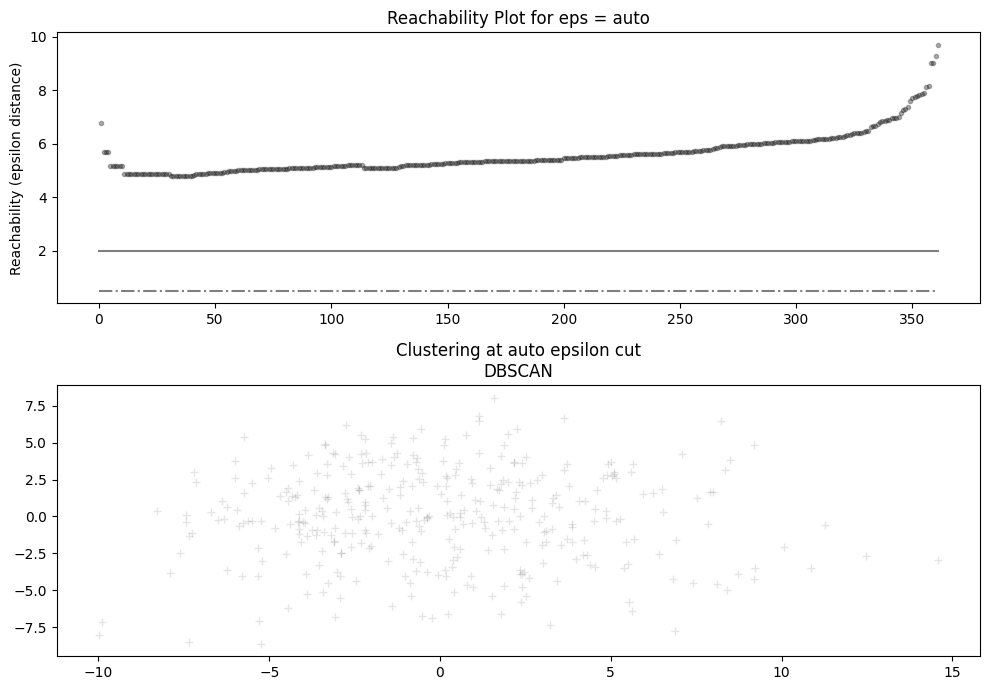

In [180]:
create_optics_plot(X_hat, X_pca, clust, eps_val = "auto")

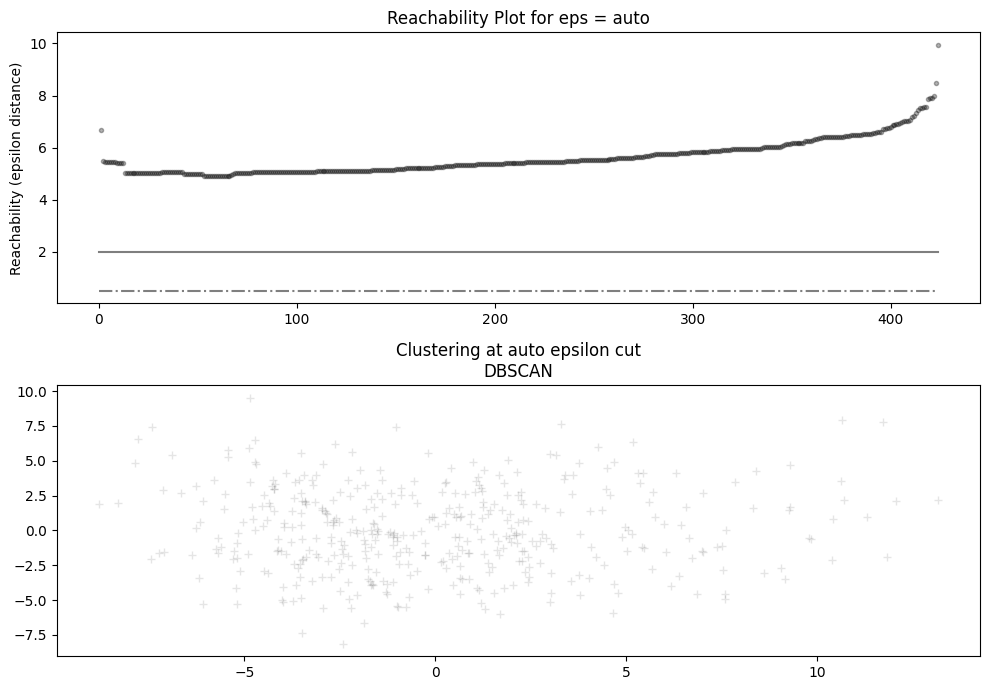

In [181]:
X_hat = blue_normalized
clust = OPTICS(min_samples=20, cluster_method='dbscan')

clust.fit(X_hat)

np.unique(clust.labels_)

pca = sklearn.decomposition.PCA(n_components=2).fit(X_hat)
X_pca = pca.transform(X_hat)

create_optics_plot(X_hat, X_pca, clust, eps_val="auto")

Now we are back to struggling to find any clear dense regions that suggest similar matches for both red aand blue winning. This can of course suggest that using our parameters that every game was sufficiently different from eachother, but we are also making our data more and more sparse and therefore reducing the number of points that could create these dense areas. And we will also try to look into this with the full data.